# VRU-Six Separation Test

Three architectures on a delayed-copy memory task — the kind of task that punishes long-sequence failure.

**Models:** LSTM baseline · VRU-minimal (φ scalar only) · VRU-six (all six verticals)

**Task:** signal appears in first 100 timesteps, model must reproduce it after N steps of distractor noise. Tests held memory, not local prediction.

**What we're looking for:** does VRU-six hold accuracy at long delays where the others collapse.

Runtime: ~15-25 min on T4. Run cells top to bottom.

In [1]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Torch: {torch.__version__}')

Device: cuda
Torch: 2.10.0+cu128


## Task: delayed copy with distractors

Signal in first 10 timesteps. Distractor noise for `delay` steps. Model must output the original signal at the end. Long delays = long memory required.

In [2]:
SIGNAL_LEN = 10
SIGNAL_DIM = 4

def make_batch(batch_size, delay, device):
    """Returns (x, y, output_mask). x has signal + distractor + recall_cue.
    y is the signal repeated at recall positions. Mask says where to score."""
    total_len = SIGNAL_LEN + delay + SIGNAL_LEN
    x = torch.zeros(total_len, batch_size, SIGNAL_DIM + 1, device=device)
    y = torch.zeros(total_len, batch_size, SIGNAL_DIM, device=device)
    mask = torch.zeros(total_len, batch_size, device=device)

    # signal phase: random signal in first SIGNAL_DIM channels
    signal = torch.randn(SIGNAL_LEN, batch_size, SIGNAL_DIM, device=device)
    x[:SIGNAL_LEN, :, :SIGNAL_DIM] = signal

    # distractor phase: noise
    x[SIGNAL_LEN:SIGNAL_LEN+delay, :, :SIGNAL_DIM] = torch.randn(delay, batch_size, SIGNAL_DIM, device=device) * 0.3

    # recall cue: last channel = 1 during recall phase
    x[SIGNAL_LEN+delay:, :, SIGNAL_DIM] = 1.0

    # target: reproduce signal at recall positions
    y[SIGNAL_LEN+delay:, :, :] = signal
    mask[SIGNAL_LEN+delay:, :] = 1.0

    return x, y, mask

# sanity check
x, y, m = make_batch(2, 100, device)
print(f'Shapes: x={x.shape}, y={y.shape}, mask={m.shape}')
print(f'Mask sum (should be 2*10=20): {m.sum().item()}')

Shapes: x=torch.Size([120, 2, 5]), y=torch.Size([120, 2, 4]), mask=torch.Size([120, 2])
Mask sum (should be 2*10=20): 20.0


## Models

In [3]:
PHI = 4.0 / math.pi
PI_RATIO = math.pi / 4.0
HIDDEN = 64
INPUT_DIM = SIGNAL_DIM + 1
OUTPUT_DIM = SIGNAL_DIM

class LSTMBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(INPUT_DIM, HIDDEN)
        self.out = nn.Linear(HIDDEN, OUTPUT_DIM)
    def forward(self, x):
        h, _ = self.lstm(x)
        return self.out(h)

class VRUMinimal(nn.Module):
    """Just the phi scalar. No verticals."""
    def __init__(self):
        super().__init__()
        self.Wx = nn.Linear(INPUT_DIM, HIDDEN)
        self.Wh = nn.Linear(HIDDEN, HIDDEN)
        self.out = nn.Linear(HIDDEN, OUTPUT_DIM)
    def forward(self, x):
        T, B, _ = x.shape
        h = torch.zeros(B, HIDDEN, device=x.device)
        outs = []
        for t in range(T):
            h = torch.tanh(self.Wx(x[t]) + PHI * self.Wh(h))
            outs.append(self.out(h))
        return torch.stack(outs)

In [4]:
class VRUSix(nn.Module):
    """
    Six verticals:
      1. Memory lattice — external state, read by geometric proximity
      2. Curvature modulation — phi shifts with local information density
      3. Dual-path coupling — h at phi, g at pi_ratio, geometrically mixed
      4. Invariant tracking — drift correction toward anchor magnitude
      5. Boundary conditions — learnable entry anchors
      6. Enclosing geometry — outgoing ping reflects off boundary, returns as input
    """
    def __init__(self):
        super().__init__()
        # dual paths
        self.Wx_h = nn.Linear(INPUT_DIM, HIDDEN)
        self.Wh_h = nn.Linear(HIDDEN, HIDDEN)
        self.Wx_g = nn.Linear(INPUT_DIM, HIDDEN)
        self.Wg_g = nn.Linear(HIDDEN, HIDDEN)
        # cross-path coupling (geometric, no gating)
        self.couple_hg = nn.Linear(HIDDEN, HIDDEN, bias=False)
        self.couple_gh = nn.Linear(HIDDEN, HIDDEN, bias=False)
        # memory lattice — fixed slot count, positions in hidden space
        self.lattice_size = 16
        self.M = nn.Parameter(torch.randn(self.lattice_size, HIDDEN) * 0.1)
        self.lattice_write = nn.Linear(HIDDEN, HIDDEN)
        # boundary anchors (vertical 5)
        self.anchor_h = nn.Parameter(torch.randn(HIDDEN) * 0.1 + 1.27 / math.sqrt(HIDDEN))
        self.anchor_g = nn.Parameter(torch.randn(HIDDEN) * 0.1 + 0.79 / math.sqrt(HIDDEN))
        # echo / enclosing geometry (vertical 6)
        self.echo_out = nn.Linear(HIDDEN, HIDDEN)
        self.echo_return = nn.Linear(HIDDEN, HIDDEN)
        # output combines h, g, and lattice signature
        self.out = nn.Linear(HIDDEN * 2 + self.lattice_size, OUTPUT_DIM)

    def forward(self, x):
        T, B, _ = x.shape
        # vertical 5: boundary entry
        h = self.anchor_h.unsqueeze(0).expand(B, -1).contiguous()
        g = self.anchor_g.unsqueeze(0).expand(B, -1).contiguous()
        # invariant anchor — what magnitude should stay near
        invariant_target = (self.anchor_h.pow(2).sum() + self.anchor_g.pow(2).sum()).detach()

        prev_mag = torch.zeros(B, device=x.device)
        outs = []
        for t in range(T):
            xt = x[t]  # [B, INPUT_DIM]

            # vertical 2: curvature modulation from local information density
            mag = xt.pow(2).sum(dim=-1)  # [B]
            delta = (mag - prev_mag).abs()  # [B]
            prev_mag = mag
            phi_dyn = PHI / (1.0 + 0.1 * delta)  # [B]
            pi_dyn = PI_RATIO * (1.0 + 0.1 * delta)  # [B]

            # vertical 1: lattice read by cosine proximity to h
            h_norm = h / (h.norm(dim=-1, keepdim=True) + 1e-8)  # [B, HIDDEN]
            M_norm = self.M / (self.M.norm(dim=-1, keepdim=True) + 1e-8)  # [L, HIDDEN]
            proximity = h_norm @ M_norm.t()  # [B, L]
            # also write current state into nearest lattice slot (soft)
            write_strength = torch.softmax(proximity * 4.0, dim=-1)  # [B, L]
            # additive write — we don't mutate self.M (would break batching),
            # instead the proximity vector itself carries the signature
            lattice_sig = proximity  # [B, L]

            # vertical 6: echo / enclosing geometry
            # h pings outward, hits tanh boundary (the wall of the enclosure),
            # reflected signal returns as input to the next step
            outgoing = self.echo_out(h)
            wall = torch.tanh(outgoing)  # the enclosure boundary
            echo = self.echo_return(wall)

            # vertical 3: dual-path update with geometric mixing
            h_pre = self.Wx_h(xt) + phi_dyn.unsqueeze(-1) * self.Wh_h(h) + self.couple_gh(g) + 0.15 * echo
            g_pre = self.Wx_g(xt) + pi_dyn.unsqueeze(-1) * self.Wg_g(g) + self.couple_hg(h)
            h_new = torch.tanh(h_pre)
            g_new = torch.tanh(g_pre)

            # vertical 4: invariant correction toward anchor magnitude
            current_mag = h_new.pow(2).sum(dim=-1) + g_new.pow(2).sum(dim=-1)  # [B]
            ratio = torch.sqrt(invariant_target / (current_mag + 1e-6))  # [B]
            # soft correction — pull, don't snap
            correction = 0.85 + 0.15 * ratio  # [B]
            h = h_new * correction.unsqueeze(-1)
            g = g_new * correction.unsqueeze(-1)

            feature = torch.cat([h, g, lattice_sig], dim=-1)
            outs.append(self.out(feature))

        return torch.stack(outs)

# parameter count comparison
for cls in [LSTMBaseline, VRUMinimal, VRUSix]:
    m = cls()
    n = sum(p.numel() for p in m.parameters())
    print(f'{cls.__name__}: {n:,} params')

LSTMBaseline: 18,436 params
VRUMinimal: 4,804 params
VRUSix: 31,492 params


## Training

Train each model on the copy task across a range of delays. Track recall MSE at each delay length.

In [5]:
def masked_mse(pred, y, mask):
    diff = (pred - y).pow(2).sum(dim=-1)  # [T, B]
    return (diff * mask).sum() / (mask.sum() + 1e-8)

def train_model(model_cls, delays_train, n_steps=2000, batch_size=16, lr=3e-3, seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = model_cls().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for step in range(n_steps):
        # curriculum: sample delay from training range
        delay = int(np.random.choice(delays_train))
        x, y, mask = make_batch(batch_size, delay, device)
        pred = model(x)
        loss = masked_mse(pred, y, mask)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        losses.append(loss.item())
        if (step + 1) % 200 == 0:
            recent = np.mean(losses[-100:])
            print(f'  step {step+1:4d}  loss {recent:.5f}')
    return model, losses

def eval_model(model, delays_test, batch_size=32, n_batches=4):
    model.eval()
    results = {}
    with torch.no_grad():
        for delay in delays_test:
            losses = []
            for _ in range(n_batches):
                x, y, mask = make_batch(batch_size, delay, device)
                pred = model(x)
                losses.append(masked_mse(pred, y, mask).item())
            results[delay] = np.mean(losses)
    return results

In [6]:
# train on short-medium delays, test on full range including extrapolation
DELAYS_TRAIN = [50, 100, 200, 400]
DELAYS_TEST = [50, 100, 200, 400, 800, 1500, 3000]

all_results = {}

for cls in [LSTMBaseline, VRUMinimal, VRUSix]:
    name = cls.__name__
    print(f'\n=== Training {name} ===')
    model, _ = train_model(cls, DELAYS_TRAIN, n_steps=2000, seed=0)
    print(f'  evaluating...')
    res = eval_model(model, DELAYS_TEST)
    all_results[name] = res
    for d, v in res.items():
        print(f'    delay {d:5d}: {v:.5f}')


=== Training LSTMBaseline ===
  step  200  loss 4.00925
  step  400  loss 4.00808
  step  600  loss 3.99700
  step  800  loss 4.02770
  step 1000  loss 3.99171
  step 1200  loss 4.05235
  step 1400  loss 3.99219
  step 1600  loss 4.01833
  step 1800  loss 4.00607
  step 2000  loss 4.01089
  evaluating...
    delay    50: 3.80625
    delay   100: 4.09629
    delay   200: 3.96422
    delay   400: 3.91421
    delay   800: 3.98972
    delay  1500: 4.14288
    delay  3000: 4.02508

=== Training VRUMinimal ===
  step  200  loss 4.01936
  step  400  loss 4.01352
  step  600  loss 3.99940
  step  800  loss 4.03099
  step 1000  loss 3.99375
  step 1200  loss 4.05454
  step 1400  loss 3.99363
  step 1600  loss 4.02000
  step 1800  loss 4.00818
  step 2000  loss 4.01194
  evaluating...
    delay    50: 3.80629
    delay   100: 4.09753
    delay   200: 3.96315
    delay   400: 3.91612
    delay   800: 3.99137
    delay  1500: 4.14511
    delay  3000: 4.03043

=== Training VRUSix ===
  step  200  

   Delay |       LSTM |    VRU-min |    VRU-six
--------------------------------------------------
      50 |    3.80625 |    3.80629 |    3.88699
     100 |    4.09629 |    4.09753 |    4.15095
     200 |    3.96422 |    3.96315 |    4.04112
     400 |    3.91421 |    3.91612 |    3.98991
     800 |    3.98972 |    3.99137 |    4.04967
    1500 |    4.14288 |    4.14511 |    4.21979
    3000 |    4.02508 |    4.03043 |    4.07777


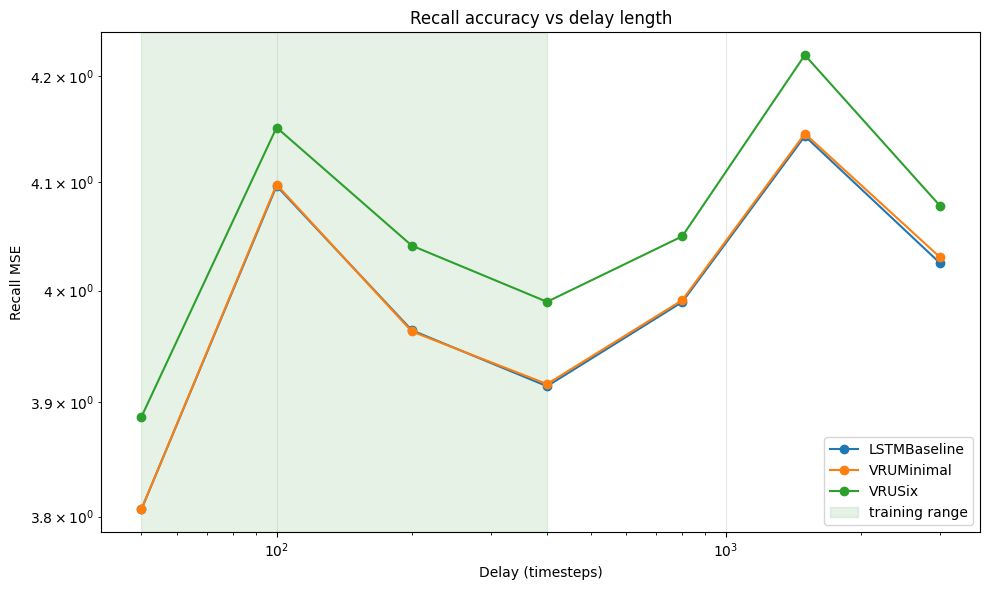

In [7]:
# results table
print(f"{'Delay':>8} | {'LSTM':>10} | {'VRU-min':>10} | {'VRU-six':>10}")
print('-' * 50)
for d in DELAYS_TEST:
    lstm_v = all_results['LSTMBaseline'][d]
    vmin_v = all_results['VRUMinimal'][d]
    vsix_v = all_results['VRUSix'][d]
    marker = ''
    if vsix_v < lstm_v and vsix_v < vmin_v:
        marker = '  <-- VRU-six best'
    print(f'{d:>8} | {lstm_v:>10.5f} | {vmin_v:>10.5f} | {vsix_v:>10.5f}{marker}')

# plot
fig, ax = plt.subplots(figsize=(10, 6))
for name in ['LSTMBaseline', 'VRUMinimal', 'VRUSix']:
    ys = [all_results[name][d] for d in DELAYS_TEST]
    ax.plot(DELAYS_TEST, ys, marker='o', label=name)
ax.set_xlabel('Delay (timesteps)')
ax.set_ylabel('Recall MSE')
ax.set_yscale('log')
ax.set_xscale('log')
ax.axvspan(50, 400, alpha=0.1, color='green', label='training range')
ax.legend()
ax.set_title('Recall accuracy vs delay length')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Multi-seed run (run if first results are interesting)

Single seed = single trajectory. If the first run shows separation, run this to check it's not just lucky initialization.

In [ ]:
SEEDS = [0, 1, 2]
multi_results = {name: {d: [] for d in DELAYS_TEST} for name in ['LSTMBaseline', 'VRUMinimal', 'VRUSix']}

for seed in SEEDS:
    print(f'\n--- seed {seed} ---')
    for cls in [LSTMBaseline, VRUMinimal, VRUSix]:
        name = cls.__name__
        print(f'  {name}...')
        model, _ = train_model(cls, DELAYS_TRAIN, n_steps=2000, seed=seed)
        res = eval_model(model, DELAYS_TEST)
        for d, v in res.items():
            multi_results[name][d].append(v)

print(f"\n{'Delay':>8} | {'LSTM (mean±std)':>20} | {'VRU-min (mean±std)':>22} | {'VRU-six (mean±std)':>22}")
print('-' * 80)
for d in DELAYS_TEST:
    row = f'{d:>8} | '
    for name in ['LSTMBaseline', 'VRUMinimal', 'VRUSix']:
        vals = multi_results[name][d]
        mean = np.mean(vals)
        std = np.std(vals)
        row += f'{mean:.5f} ± {std:.5f} | '
    print(row)